<a href="https://colab.research.google.com/github/velizabetho/mineria/blob/main/Tarea_Canasta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Contexto: Registro de transacciones de varios productos en dentro de la misma compra

1. Importación de Librerias

In [5]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [2]:
!pip install category_encoders
!pip install squarify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.3 MB/s eta 0:00:00


In [6]:
import numpy as np
import pandas as pd
import squarify
import matplotlib.pyplot as plt

# for market basket analysis
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

2. Lectura de Datos

In [9]:
dfa = pd.read_csv("/content/bakery_sales_revised.csv")

In [ ]:
dfa.head(10)

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,10/30/2016 9:58,morning,weekend
1,2,Scandinavian,10/30/2016 10:05,morning,weekend
2,2,Scandinavian,10/30/2016 10:05,morning,weekend
3,3,Hot chocolate,10/30/2016 10:07,morning,weekend
4,3,Jam,10/30/2016 10:07,morning,weekend
5,3,Cookies,10/30/2016 10:07,morning,weekend
6,4,Muffin,10/30/2016 10:08,morning,weekend
7,5,Coffee,10/30/2016 10:13,morning,weekend
8,5,Pastry,10/30/2016 10:13,morning,weekend
9,5,Bread,10/30/2016 10:13,morning,weekend


3. Visualizacion de Datos

In [ ]:
dfa.shape

(20507, 5)

In [ ]:
dfa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


In [ ]:
dfa['period_day'].unique().tolist()

['morning', 'afternoon', 'evening', 'night']

In [ ]:
dfa['weekday_weekend'].unique().tolist()

['weekend', 'weekday']

In [ ]:
dfa.isnull().sum()

,0
Transaction,0
Item,0
date_time,0
period_day,0
weekday_weekend,0


In [ ]:
dfa.isnull().any().any()

np.False_

In [ ]:
dfa['Item'].unique().tolist()

['Bread',
 'Scandinavian',
 'Hot chocolate',
 'Jam',
 'Cookies',
 'Muffin',
 'Coffee',
 'Pastry',
 'Medialuna',
 'Tea',
 'Tartine',
 'Basket',
 'Mineral water',
 'Farm House',
 'Fudge',
 'Juice',
 "Ella's Kitchen Pouches",
 'Victorian Sponge',
 'Frittata',
 'Hearty & Seasonal',
 'Soup',
 'Pick and Mix Bowls',
 'Smoothies',
 'Cake',
 'Mighty Protein',
 'Chicken sand',
 'Coke',
 'My-5 Fruit Shoot',
 'Focaccia',
 'Sandwich',
 'Alfajores',
 'Eggs',
 'Brownie',
 'Dulce de Leche',
 'Honey',
 'The BART',
 'Granola',
 'Fairy Doors',
 'Empanadas',
 'Keeping It Local',
 'Art Tray',
 'Bowl Nic Pitt',
 'Bread Pudding',
 'Adjustment',
 'Truffles',
 'Chimichurri Oil',
 'Bacon',
 'Spread',
 'Kids biscuit',
 'Siblings',
 'Caramel bites',
 'Jammie Dodgers',
 'Tiffin',
 'Olum & polenta',
 'Polenta',
 'The Nomad',
 'Hack the stack',
 'Bakewell',
 'Lemon and coconut',
 'Toast',
 'Scone',
 'Crepes',
 'Vegan mincepie',
 'Bare Popcorn',
 'Muesli',
 'Crisps',
 'Pintxos',
 'Gingerbread syrup',
 'Panatone',
 'B

In [ ]:
dfa.describe()

,Transaction
count,20507.000000
mean,4976.202370
std,2796.203001
min,1.000000
25%,2552.000000
50%,5137.000000
75%,7357.000000
max,9684.000000


In [ ]:
transactions = dfa.groupby("Transaction")["Item"].apply(list)

transactions.head(10)

,Item
Transaction,
1,[Bread]
2,"[Scandinavian, Scandinavian]"
3,"[Hot chocolate, Jam, Cookies]"
4,[Muffin]
5,"[Coffee, Pastry, Bread]"
6,"[Medialuna, Pastry, Muffin]"
7,"[Medialuna, Pastry, Coffee, Tea]"
8,"[Pastry, Bread]"
9,"[Bread, Muffin]"


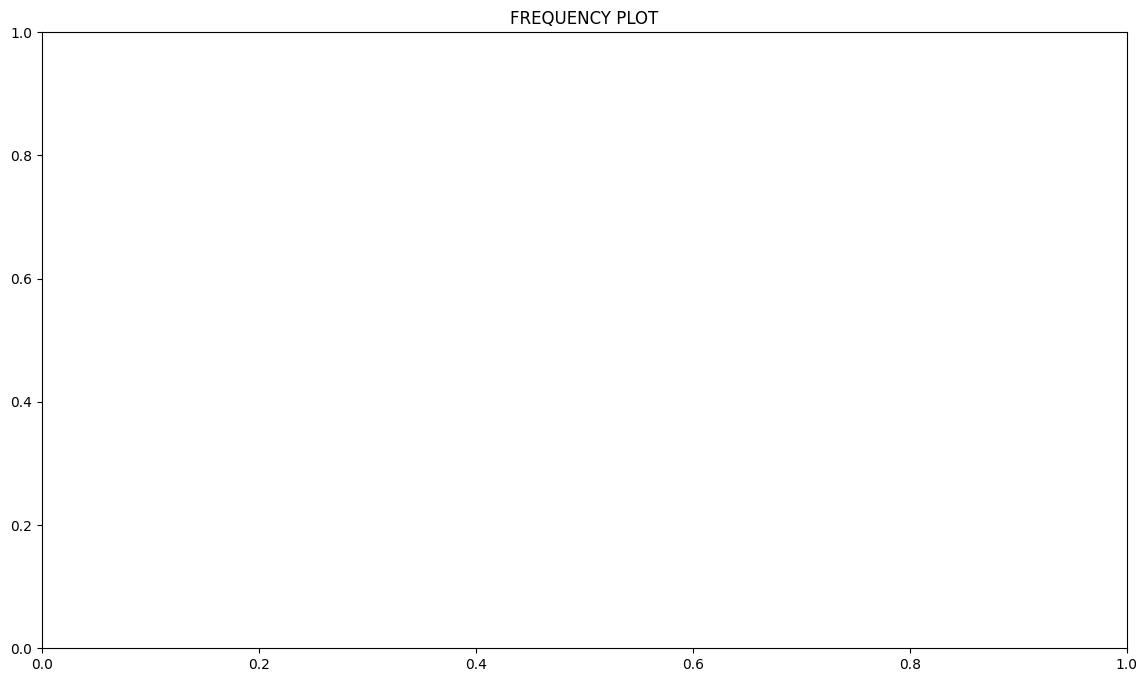

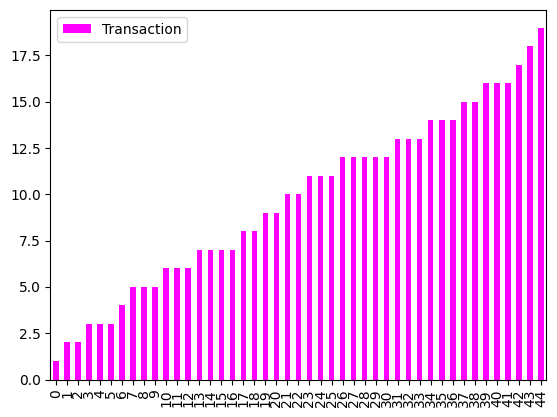

In [ ]:
plt.figure(figsize=(14,8))
plt.title("FREQUENCY PLOT")
cnt = 45 # plot only first 'cnt' values
color = plt.cm.spring(np.linspace(0, 1, cnt))
dfa.head(cnt).plot.bar(color = color)
plt.xticks(rotation = 'vertical')
plt.grid(False)
plt.axis('on')
plt.show()

4. Transformacion de datos

In [ ]:
transactions = dfa.groupby('Transaction')['Item'].apply(list).tolist()

Agrupar los productos por transaccion

In [ ]:
transactions[:5]

[['Bread'],
 ['Scandinavian', 'Scandinavian'],
 ['Hot chocolate', 'Jam', 'Cookies'],
 ['Muffin'],
 ['Coffee', 'Pastry', 'Bread']]

5. Resultados

In [ ]:
#Aplicamos TransactionEncoder esto transforma la informaicon en verdadero / falso
#Cada fila representa una a transaccion y cada fila representa un producto
te = TransactionEncoder()

data = te.fit_transform(transactions)

data = pd.DataFrame(data, columns=te.columns_)

data.head()

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
#aplicamos Apriori que nos entrega un conjunto frecuentes
#
freq_rules = apriori(
    data,
    min_support=0.01,
    use_colnames=True
)

freq_rules
#La columna supp corresponde a qué tan frecuente aparece esa combinacion dentro de las transacciones totales

,support,itemsets
0,0.036344,(Alfajores)
1,0.016059,(Baguette)
2,0.327205,(Bread)
3,0.040042,(Brownie)
4,0.103856,(Cake)
...,...,...
56,0.023666,"(Toast, Coffee)"
57,0.014369,"(Sandwich, Tea)"
58,0.010037,"(Bread, Cake, Coffee)"
59,0.011199,"(Bread, Pastry, Coffee)"


In [ ]:
#Pero Apriori solo entrega conjunto de datos frecuentes. Para ver reglas ej para nuestro dt qué producto esta frecuente con otro producto entonces:

rules = association_rules(
    freq_rules,
    metric='confidence',
    min_threshold=0.1
)


In [ ]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Alfajores),(Bread),0.036344,0.327205,0.010354,0.284884,0.870657,1.0,-0.001538,0.940818,-0.133570,0.029315,-0.062904,0.158264
1,(Alfajores),(Coffee),0.036344,0.478394,0.019651,0.540698,1.130235,1.0,0.002264,1.135648,0.119574,0.039693,0.119446,0.290888
2,(Brownie),(Bread),0.040042,0.327205,0.010777,0.269129,0.822508,1.0,-0.002326,0.920538,-0.183536,0.030231,-0.086321,0.151032
3,(Cake),(Bread),0.103856,0.327205,0.023349,0.224822,0.687097,1.0,-0.010633,0.867923,-0.336947,0.057269,-0.152177,0.148091
4,(Bread),(Coffee),0.327205,0.478394,0.090016,0.275105,0.575059,1.0,-0.066517,0.719561,-0.523431,0.125794,-0.389737,0.231634
5,(Coffee),(Bread),0.478394,0.327205,0.090016,0.188163,0.575059,1.0,-0.066517,0.828731,-0.586210,0.125794,-0.206665,0.231634
6,(Cookies),(Bread),0.054411,0.327205,0.014474,0.266019,0.813004,1.0,-0.003329,0.916638,-0.195651,0.039424,-0.090943,0.155128
7,(Hot chocolate),(Bread),0.058320,0.327205,0.013418,0.230072,0.703144,1.0,-0.005665,0.873841,-0.309550,0.036059,-0.144373,0.135540
8,(Medialuna),(Bread),0.061807,0.327205,0.016904,0.273504,0.835879,1.0,-0.003319,0.926082,-0.173062,0.045429,-0.079818,0.162584
9,(Pastry),(Bread),0.086107,0.327205,0.029160,0.338650,1.034977,1.0,0.000985,1.017305,0.036980,0.075908,0.017011,0.213884


In [ ]:
#entonces ahora tenemos reglas donde el antecedente sea "Bread"
rules_bread = rules[rules['antecedents'].apply(lambda x: 'Bread' in x)]

rules_bread

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4,(Bread),(Coffee),0.327205,0.478394,0.090016,0.275105,0.575059,1.0,-0.066517,0.719561,-0.523431,0.125794,-0.389737,0.231634
34,"(Bread, Cake)",(Coffee),0.023349,0.478394,0.010037,0.429864,0.898557,1.0,-0.001133,0.914880,-0.103617,0.020413,-0.093039,0.225422
35,"(Bread, Coffee)",(Cake),0.090016,0.103856,0.010037,0.111502,1.073621,1.0,0.000688,1.008606,0.075356,0.054598,0.008532,0.104073
37,"(Bread, Pastry)",(Coffee),0.029160,0.478394,0.011199,0.384058,0.802807,1.0,-0.002751,0.846843,-0.201920,0.022563,-0.180857,0.203734
38,"(Bread, Coffee)",(Pastry),0.090016,0.086107,0.011199,0.124413,1.444872,1.0,0.003448,1.043749,0.338354,0.067905,0.041916,0.127237


In [ ]:
#y basado en la regla anterior deseas ven la informaicones mas relevantes ordenadas por confianza:
rules_bread.sort_values(by='confidence', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
34,"(Bread, Cake)",(Coffee),0.023349,0.478394,0.010037,0.429864,0.898557,1.0,-0.001133,0.914880,-0.103617,0.020413,-0.093039,0.225422
37,"(Bread, Pastry)",(Coffee),0.029160,0.478394,0.011199,0.384058,0.802807,1.0,-0.002751,0.846843,-0.201920,0.022563,-0.180857,0.203734
4,(Bread),(Coffee),0.327205,0.478394,0.090016,0.275105,0.575059,1.0,-0.066517,0.719561,-0.523431,0.125794,-0.389737,0.231634
38,"(Bread, Coffee)",(Pastry),0.090016,0.086107,0.011199,0.124413,1.444872,1.0,0.003448,1.043749,0.338354,0.067905,0.041916,0.127237
35,"(Bread, Coffee)",(Cake),0.090016,0.103856,0.010037,0.111502,1.073621,1.0,0.000688,1.008606,0.075356,0.054598,0.008532,0.104073
